In [2]:
# Librairies
import os
import pandas as pd
import numpy as np

# Modules
import climatic as clim
import dichotomy as dic

# Plots
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.pylab as pl
from matplotlib.font_manager import FontProperties   

recharge = clim.surfex("C:/Users/alexa/Dropbox/HydroModPy/data.h5", sim='ACC1', var='REC', sce='historic', resample='M').period_data.mean()
outlets = pd.read_csv("C:/Users/alexa/Dropbox/HydroModPy/outlets_norm.txt", sep='\t', header=None, engine='python')

for idx, serie in outlets[5:].iterrows():
    
    outlet = outlets.loc[[idx]]
    site = outlet[[0]].values[0][0]
    
    print('#################### SITE '+str(idx)+' : '+site.upper()+' ####################')
    
    dic.delimit_size(dem_path="C:/Users/alexa/Dropbox/HydroModPy/MNT_TOPO_BATH_75m.tif",
                     watershed=site, outlet=outlet,
                     snap_dist=500, buff_dist=1000, save_dem=True, type_obs='streams',
                     data_path = "C:/Users/alexa/Dropbox/HydroModPy/_data/",
                     tmp_path=os.path.dirname(os.getcwd())+'\\tmp\\',
                     out_path="C:/Users/alexa/Dropbox/HydroModPy/")
    
    dic.dichotomy_loop(first=1, last=10000, gap=10,
                       df=pd.DataFrame(),
                       watershed=site,
                       climatic=[recharge*30/1000], lay_number=1, thick=100, porosity=0.01,
                       type_obs='streams', type_time='s', sim_id='identify',
                       data_path = "C:/Users/alexa/Dropbox/HydroModPy/_data/",
                       tmp_path=os.path.dirname(os.getcwd())+'\\tmp\\',
                       out_path="C:/Users/alexa/Dropbox/HydroModPy/")
   


#################### SITE 5 : MUE ####################
- Delete previous : YES

==> Simulation : 0
    Parameters : s_mue_1_100_5000.5_0.022_108.487_0.01
    KR = 5000.5
    Condition = 2.87
    Ecart = 4999.5

==> Simulation : 1
    Parameters : s_mue_1_100_7500.25_0.022_162.72_0.01
    KR = 7500.25
    Condition = 1.1
    Ecart = 2499.75

==> Simulation : 2
    Parameters : s_mue_1_100_8750.125_0.022_189.836_0.01
    KR = 8750.12
    Condition = 1.01
    Ecart = 1249.88

==> Simulation : 3
    Parameters : s_mue_1_100_9375.062_0.022_203.394_0.01
    KR = 9375.06
    Condition = 1.0
    Ecart = 624.94

==> Simulation : 4
    Parameters : s_mue_1_100_9062.594_0.022_196.615_0.01
    KR = 9062.59
    Condition = 1.01
    Ecart = 312.47

==> Simulation : 5
    Parameters : s_mue_1_100_9218.828_0.022_200.005_0.01
    KR = 9218.83
    Condition = 1.0
    Ecart = 156.23

==> Simulation : 6
    Parameters : s_mue_1_100_9140.711_0.022_198.31_0.01
    KR = 9140.71
    Condition = 1.0
    Ecart 

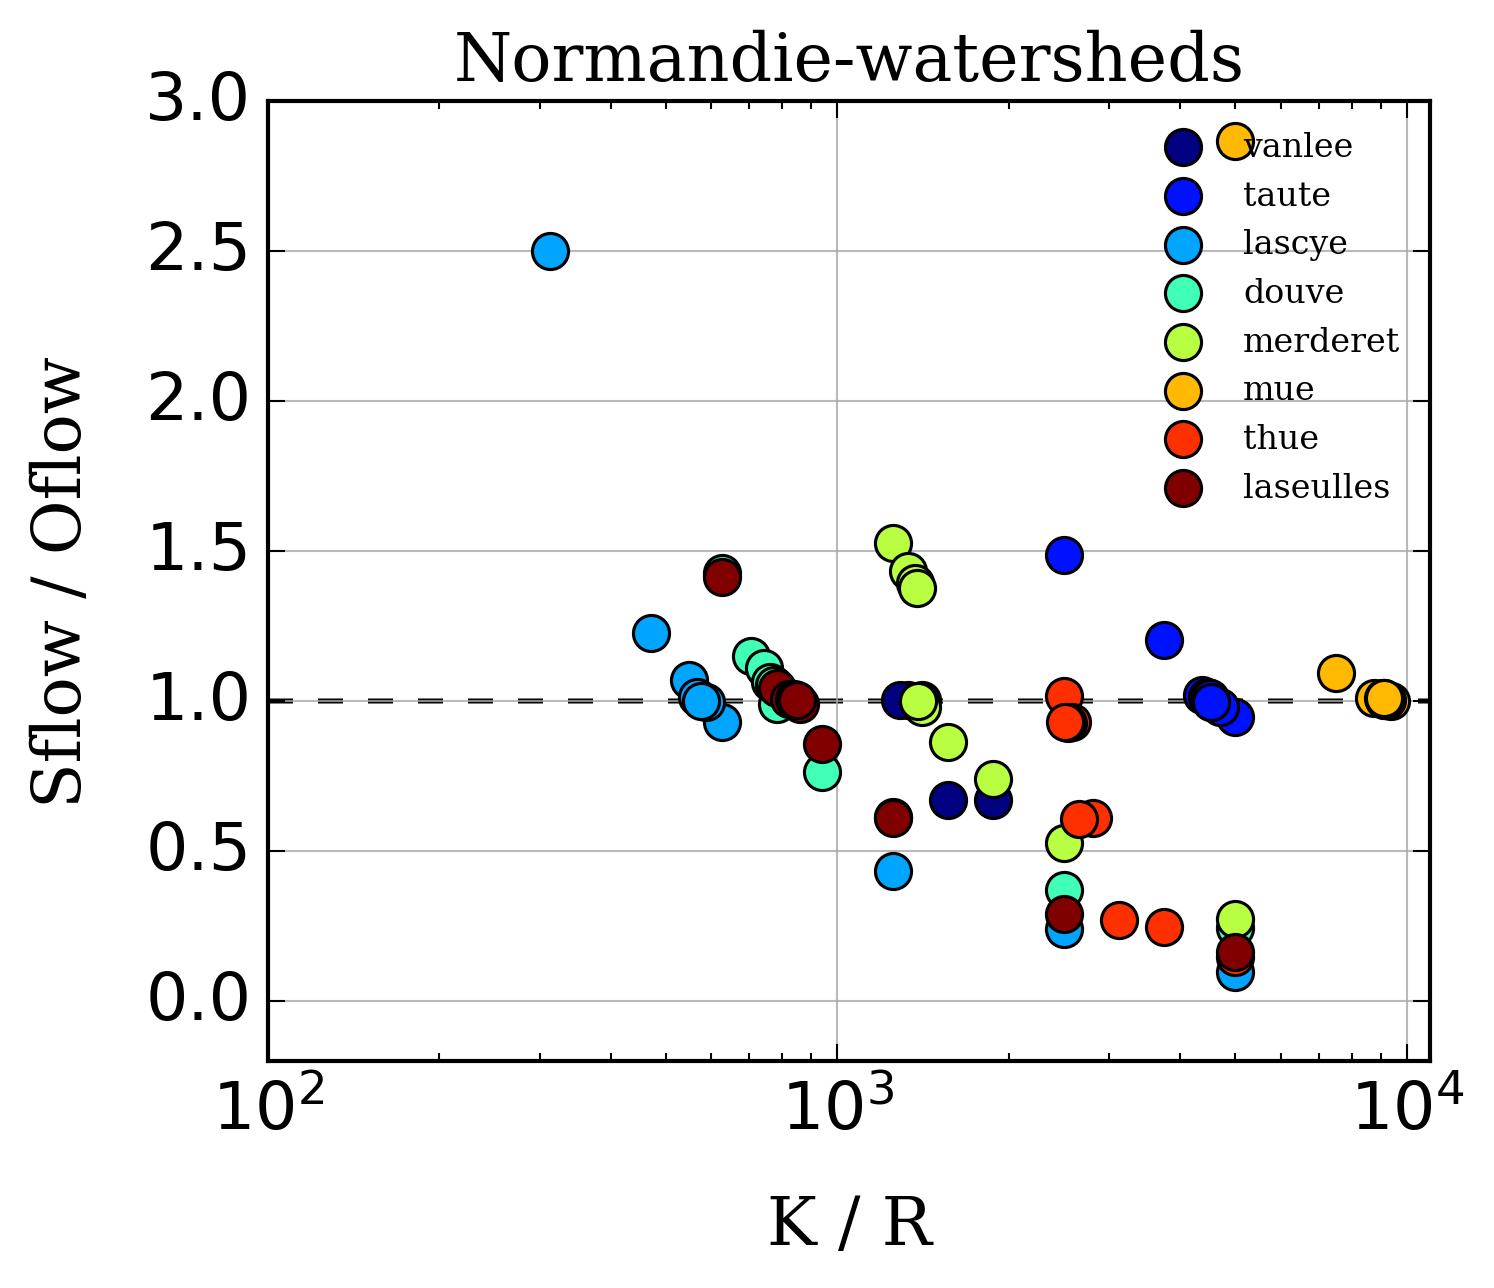

In [3]:
#%% Parameters : for plot

mpl.style.use('classic')
mpl.rcParams["figure.facecolor"] = 'white'
mpl.rcParams['grid.color'] = 'darkgrey'
mpl.rcParams['grid.linestyle'] = '-'
mpl.rcParams['grid.alpha'] = 0.8
mpl.rcParams['axes.axisbelow'] = True
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams['patch.force_edgecolor'] = True
mpl.rcParams['image.interpolation'] = 'nearest'
mpl.rcParams['image.resample'] = True
mpl.rcParams['axes.autolimit_mode'] = 'data' # 'round_numbers' # 
mpl.rcParams['axes.xmargin'] = 0.05
mpl.rcParams['axes.ymargin'] = 0.05
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['legend.numpoints'] = 1
mpl.rcParams['legend.scatterpoints'] = 1
mpl.rcParams['legend.edgecolor'] = 'grey'
mpl.rcParams['date.autoformatter.year'] = '%Y'
mpl.rcParams['date.autoformatter.month'] = '%Y-%m'
mpl.rcParams['date.autoformatter.day'] = '%Y-%m-%d'
mpl.rcParams['date.autoformatter.hour'] = '%H:%M'
mpl.rcParams['date.autoformatter.minute'] = '%H:%M:%S'
mpl.rcParams['date.autoformatter.second'] = '%H:%M:%S'
smal = 8
medium = 16
large = 20
plt.rc('font', size=medium)                         # controls default text sizes **font
plt.rc('figure', titlesize=large)                   # fontsize of the figure title
plt.rc('legend', fontsize=smal)                     # legend fontsize
plt.rc('axes', titlesize=medium, labelpad=10)        # fontsize of the axes title
plt.rc('axes', labelsize=medium, labelpad=12)        # fontsize of the x and y labels
plt.rc('xtick', labelsize=medium)                   # fontsize of the tick labels
plt.rc('ytick', labelsize=medium)                   # fontsize of the tick labels
fontprop = FontProperties()
fontprop.set_family('serif') # for x and y label
fontdic = {'family' : 'serif'} # for legend

#%% Plot : figure

toget = 'Normandie-watersheds'
fig, ax = plt.subplots(figsize=(5,4))
colors = pl.cm.jet(np.linspace(0,1,8))
site_list = outlets[0]
for i, name in enumerate(site_list):
    path = "C:/Users/alexa/Dropbox/HydroModPy/"+name+'//'
    file = pd.read_csv(path+name+'_calibration.csv', sep='\t', header=0)
    ax.axhline(1, color='k', lw=1, ls='--', zorder=0)
    ax.scatter(file.Kr, (file.Sflow / file.Oflow), s=75, marker='o', edgecolor='k', lw=0.75, color=colors[i], label=name)
    ax.set_xscale('log')
    ax.legend(fontsize=7, frameon=False, prop=fontdic)
    ax.set_xlim(100,11000)
    ax.set_ylim(-0.2,3)
    ax.set_xlabel('K / R', fontproperties=fontprop)
    ax.set_ylabel('Sflow / Oflow', fontproperties=fontprop)
    ax.set_title(toget, fontproperties=fontprop)
    ax.grid(True)